# 0.1.5. 함수도 벡터다

In [1]:
import numpy as np

x = np.linspace(0, 1, 11)
f = x**2

print("x =", x)
print("f =", f)

x = [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
f = [0.   0.01 0.04 0.09 0.16 0.25 0.36 0.49 0.64 0.81 1.  ]


In [2]:
import sympy as sym
from sympy import exp

x = sym.Symbol('x')
a = sym.integrate(x * exp(x), (x, 0, 1))
print(f"[0, 1]에서 x * exp(x)의 적분값: {a}")

[0, 1]에서 x * exp(x)의 적분값: 1


In [3]:
for N in [5, 10, 50, 100, 1000, 10000]:
    x = np.linspace(0, 1, N)
    dx = x[1] - x[0]
    f = x
    g = np.exp(x)

    print(f"N = {N:6d}   sum f*g*dx = {np.dot(f, g) * dx:.6f}")

N =      5   sum f*g*dx = 1.362850
N =     10   sum f*g*dx = 1.155578
N =     50   sum f*g*dx = 1.027892
N =    100   sum f*g*dx = 1.013766
N =   1000   sum f*g*dx = 1.001361
N =  10000   sum f*g*dx = 1.000136


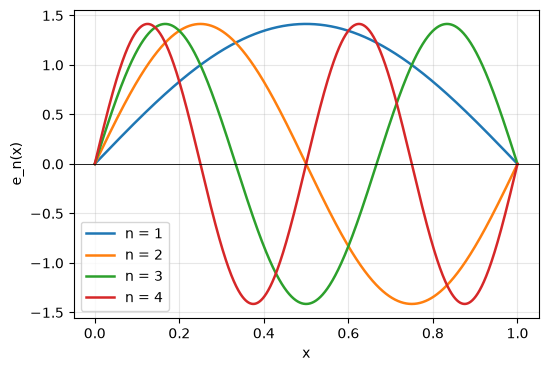

In [4]:
import matplotlib.pyplot as plt

L = 1.0
x = np.linspace(0, L, 2001)


def e(n):
    return np.sqrt(2 / L) * np.sin(n * np.pi * x / L)


fig, ax = plt.subplots(figsize=(6, 4))
for n in range(1, 5):
    ax.plot(x, e(n), lw=1.8, label=f"n = {n}")
ax.axhline(0, color="black", lw=0.6)
ax.set_xlabel("x")
ax.set_ylabel("e_n(x)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [5]:
L = 1.0
x = np.linspace(0, L, 2001)


def inner(f, g):
    return np.trapezoid(f * g, x)


def e(n):
    return np.sqrt(2 / L) * np.sin(n * np.pi * x / L)


for m, n in [(1, 1), (3, 3), (1, 2), (1, 3), (4, 8)]:
    print(f"<e{m}|e{n}> = {inner(e(m), e(n)): .6f}")

<e1|e1> =  1.000000
<e3|e3> =  1.000000
<e1|e2> =  0.000000
<e1|e3> =  0.000000
<e4|e8> =  0.000000


In [6]:
fx = x * (L - x)

cs = np.array([inner(e(n), fx) for n in range(1, 11)])

for i, c in enumerate(cs, 1):
    print(f"c{i:2d} = {c: .6f}")

c 1 =  0.182442
c 2 =  0.000000
c 3 =  0.006757
c 4 =  0.000000
c 5 =  0.001460
c 6 = -0.000000
c 7 =  0.000532
c 8 =  0.000000
c 9 =  0.000250
c10 = -0.000000


항  1개  최대오차 = 1.064e-02
항  3개  최대오차 = 2.962e-03
항  5개  최대오차 = 1.348e-03


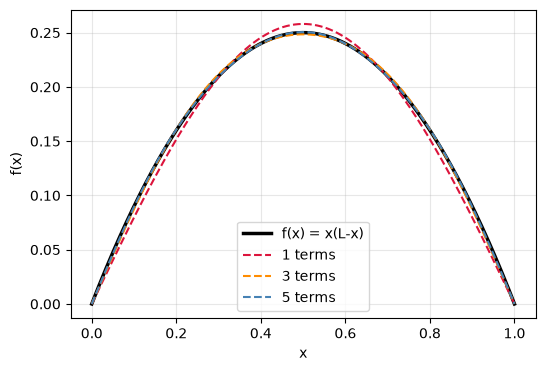

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, fx, color="black", lw=2.5, label="f(x) = x(L-x)")

for M, c in zip([1, 3, 5], ["crimson", "darkorange", "steelblue"]):
    rec = sum(cs[n - 1] * e(n) for n in range(1, M + 1))
    ax.plot(x, rec, lw=1.5, ls="--", color=c, label=f"{M} terms")
    print(f"항 {M:2d}개  최대오차 = {np.max(np.abs(fx - rec)):.3e}")

ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [8]:
print("sum c_n^2 =", np.sum(cs**2))
print("<f|f>     =", inner(fx, fx))

sum c_n^2 = 0.03333330161282389
<f|f>     = 0.03333333333333125
